# Metodologia Design Science Research (DSR)\n
\n
**Etapas de Pesquisa (Peffers et al., 2007):**\n
### 4. Demonstração (Demonstration)\n
\n
**Objetivo Acadêmico:** Este notebook avalia o modelo **SARIMAX** como um artefato estatístico avançado que integra a teoria das séries temporais com a análise multivariada. Na DSR, a demonstração serve para provar a viabilidade do artefato em um contexto real. Ao incluir variáveis exógenas (X) e sazonalidade (S), este experimento busca validar se uma estrutura estatística rígida consegue competir com a flexibilidade dos modelos de Machine Learning, elevando o rigor da comparação entre paradigmas.\n

# 07h - Modelagem Estatística: SARIMAX
O **SARIMAX** expande o ARIMA ao incluir:
1. **Seasonal (S)**: Componentes sazonais (ex: dia da semana).
2. **eXogenous (X)**: Variáveis externas que ajudam a explicar a demanda (nossas features do cardápio e temporalidade).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Carregamento Completo
df = pd.read_csv('../data/base_features_selecionadas.csv')
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')
df.set_index('data', inplace=True)

TARGET = 'total_servido'
y = df[TARGET]
X = df.drop(columns=[TARGET])

train_size = int(len(y) * 0.8)
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]

print(f"📦 Base pronta para SARIMAX ({len(X.columns)} variáveis exógenas).")

📦 Base pronta para SARIMAX (50 variáveis exógenas).


🚀 Treinando SARIMAX...

📊 Resultados Finais (SARIMAX):


,Modelo,MAE,RMSE,R2
0,SARIMAX,33.410534,43.618309,-0.480449


✅ Predições salvas em 'preds_sarimax.csv'


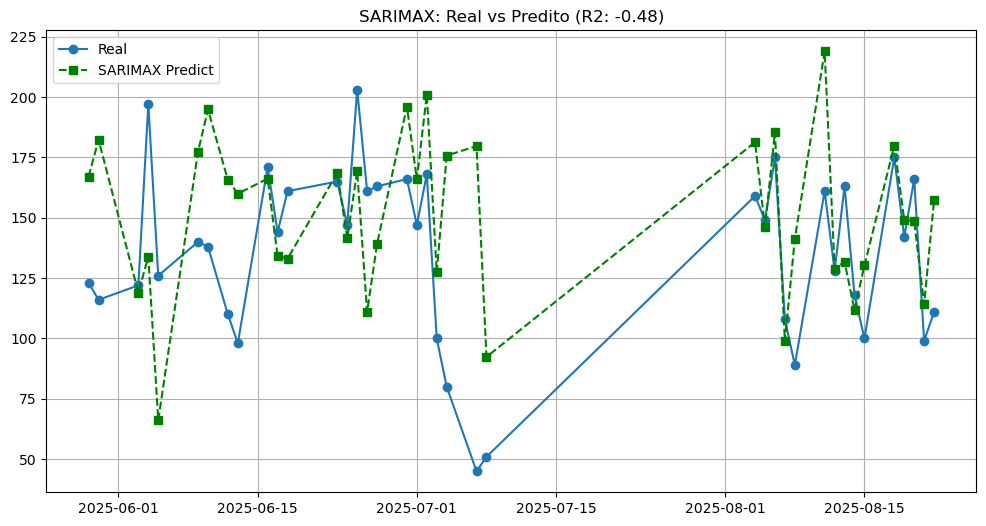

In [2]:
# 1. Ajuste e Predição do SARIMAX com Exógenas
print("🚀 Treinando SARIMAX...")
model = SARIMAX(y_train, 
                exog=X_train, 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 7))
model_fit = model.fit(disp=False)

# Forecast
forecast = model_fit.forecast(steps=len(y_test), exog=X_test)

# 2. Cálculos de Métricas
mae = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mean_squared_error(y_test, forecast))
r2 = r2_score(y_test, forecast)

df_res = pd.DataFrame([{
    'Modelo': 'SARIMAX',
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}])

print("\n📊 Resultados Finais (SARIMAX):")
display(df_res)

# 3. Salvar Predições para o Comparativo (Notebook 08)
df_preds = pd.DataFrame({
    'data': y_test.index,
    'real': y_test.values,
    'pred_sarimax': forecast.values
})
df_preds.to_csv('../data/preds_sarimax.csv', index=False)
print("✅ Predições salvas em 'preds_sarimax.csv'")

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Real', marker='o')
plt.plot(y_test.index, forecast, label='SARIMAX Predict', color='green', linestyle='--', marker='s')
plt.title(f'SARIMAX: Real vs Predito (R2: {r2:.2f})')
plt.legend()
plt.grid(True)
plt.show()